## G1: Prepare a single qubit in the zero state and apply a Hadamard gate. Describe the final behaviour of the qubit and its measurement outcomes.

In [5]:
!pip install qiskit qiskit_aer pylatexenc qiskit[visualization] matplotlib


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector
import pylatexenc

In [8]:

def experiment():
    qc = QuantumCircuit(1, 1)

    qc.h(0)

    qc.measure(0, 0)

    simulator = AerSimulator()
    compiled_circuit = transpile(qc, simulator)
    job = simulator.run(compiled_circuit, shots=1000)
    result = job.result()
    counts = result.get_counts()

    return qc, counts

circuit, counts = experiment()

print("Circuit Diagram:")
print(circuit.draw('text'))

Circuit Diagram:
     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


Measurement Results from 1000 shots: {'1': 519, '0': 481}


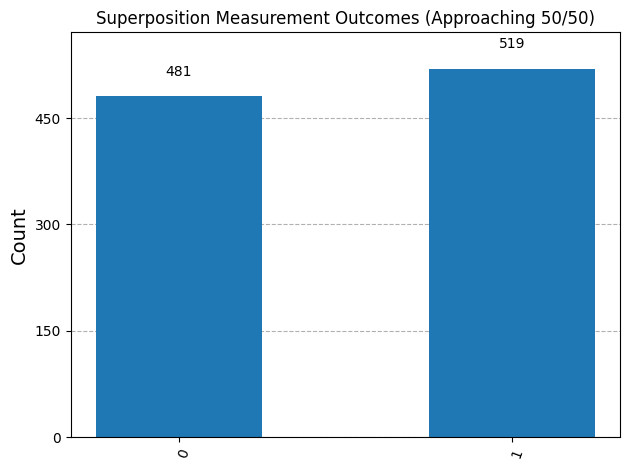

In [9]:
print(f"Measurement Results from 1000 shots: {counts}")

plot_histogram(counts, title="Superposition Measurement Outcomes (Approaching 50/50)")

In [10]:
circuit, counts = experiment()


### Initial State of the Qubit

By default, a qubit is initialized in the $|0\rangle$ state. Let's visualize its statevector and Bloch sphere representation.

Initial Statevector:
Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


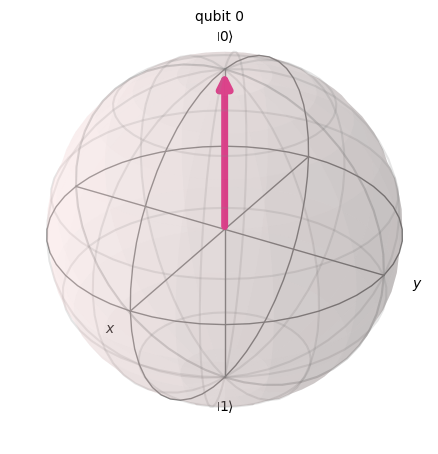

In [11]:
initial_state = Statevector.from_label('0')
print("Initial Statevector:")
print(initial_state)

plot_bloch_multivector(initial_state)

### State After Hadamard Gate



Statevector after Hadamard gate:
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


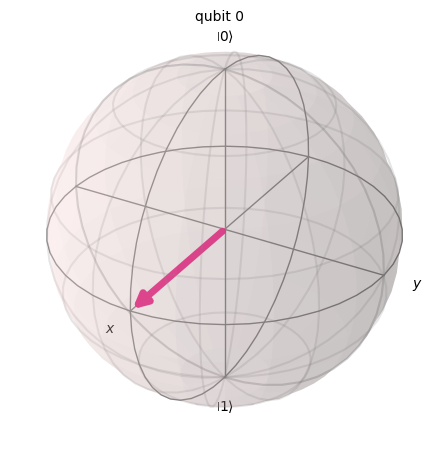

In [12]:
qc_state_only = QuantumCircuit(1, 0)
qc_state_only.h(0)

initial_state = Statevector.from_label('0')

final_state = initial_state.evolve(qc_state_only)

print("Statevector after Hadamard gate:")
print(final_state)

plot_bloch_multivector(final_state)

In [13]:
class QuantumEngine:
    def __init__(self):
        self.simulator = AerSimulator()

    def generate_random_number(self, min_val, max_val):
        """
        Generates a random integer between min_val and max_val using Quantum Superposition.
        """
        range_span = max_val - min_val
        num_qubits = range_span.bit_length()

        qc = QuantumCircuit(num_qubits, num_qubits)

        qc.h(range(num_qubits))

        qc.measure(range(num_qubits), range(num_qubits))

        compiled_circuit = transpile(qc, self.simulator)
        job = self.simulator.run(compiled_circuit, shots=1)
        result = job.result()
        counts = result.get_counts()

        binary_string = list(counts.keys())[0]
        random_int = int(binary_string, 2)

        final_number = min_val + (random_int % (range_span + 1))

        return final_number, qc

    def create_bell_pair(self):
        """
        Creates a Bell State (Entanglement) between two qubits:
        |Psi> = (|00> + |11>) / sqrt(2)
        """
        qc = QuantumCircuit(2, 2)

        qc.h(0)

        qc.cx(0, 1)

        qc.save_statevector()

        qc.measure([0, 1], [0, 1])

        return qc

engine = QuantumEngine()

In [14]:
low = 0
high = 100

random_num, rng_circuit = engine.generate_random_number(low, high)

print(f"Generated Quantum Random Number: {random_num}")

print("Circuit Diagram:")
rng_circuit.draw('text')

Generated Quantum Random Number: 34
Circuit Diagram:


┌───┐┌─┐                  
q_0: ┤ H ├┤M├──────────────────
     ├───┤└╥┘┌─┐               
q_1: ┤ H ├─╫─┤M├───────────────
     ├───┤ ║ └╥┘┌─┐            
q_2: ┤ H ├─╫──╫─┤M├────────────
     ├───┤ ║  ║ └╥┘┌─┐         
q_3: ┤ H ├─╫──╫──╫─┤M├─────────
     ├───┤ ║  ║  ║ └╥┘┌─┐      
q_4: ┤ H ├─╫──╫──╫──╫─┤M├──────
     ├───┤ ║  ║  ║  ║ └╥┘┌─┐   
q_5: ┤ H ├─╫──╫──╫──╫──╫─┤M├───
     ├───┤ ║  ║  ║  ║  ║ └╥┘┌─┐
q_6: ┤ H ├─╫──╫──╫──╫──╫──╫─┤M├
     └───┘ ║  ║  ║  ║  ║  ║ └╥┘
c: 7/══════╩══╩══╩══╩══╩══╩══╩═
           0  1  2  3  4  5  6

Measurement Counts (should be ~50/50 split between 00 and 11):
{'11': 499, '00': 501}


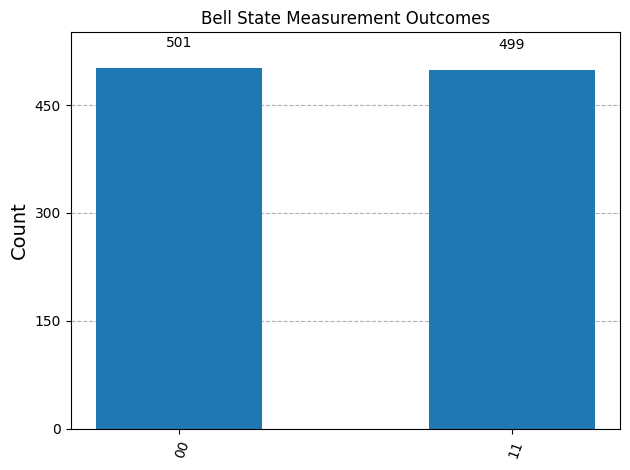

In [15]:
bell_circuit = engine.create_bell_pair()

compiled_circuit = transpile(bell_circuit, engine.simulator)
job = engine.simulator.run(compiled_circuit, shots=1000)
result = job.result()
counts = result.get_counts()

state = result.get_statevector(bell_circuit)

print("Measurement Counts (should be ~50/50 split between 00 and 11):")
print(counts)

plot_histogram(counts, title="Bell State Measurement Outcomes")